# Exploratory Data Analysis

Before building any machine learning model, it is essential to understand the dataset. Exploratory Data Analysis (EDA) helps us inspect the available features, identify data quality issues, understand the distribution of the variables, and investigate which passenger characteristics appear to be associated with survival.

In this notebook we will:

* Load the training and test datasets.
* Inspect their structure and contents.
* Examine missing values and data types.
* Explore the distribution of the target variable.
* Analyze the relationship between passenger attributes and survival.
* Identify potential opportunities for feature engineering in the next stage.

By the end of this notebook, we should have a solid understanding of the data and a clear plan for preparing it for machine learning models.


## Dataset Description

The training dataset contains one row per passenger and the following variables:

| Feature    | Description                                                                                                                                    |
| ---------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `Survived` | Target variable. `0` indicates the passenger did not survive, while `1` indicates survival. This column is only available in the training set. |
| `Pclass`   | Passenger ticket class (`1` = First, `2` = Second, `3` = Third).                                                                               |
| `Name`     | Passenger's full name.                                                                                                                         |
| `Sex`      | Passenger's sex (`male` or `female`).                                                                                                          |
| `Age`      | Passenger's age in years. Fractional values represent infants, while values ending in `.5` correspond to estimated ages.                       |
| `SibSp`    | Number of siblings and spouses aboard the Titanic.                                                                                             |
| `Parch`    | Number of parents and children aboard the Titanic. Children traveling only with a nanny have `Parch = 0`.                                      |
| `Ticket`   | Ticket number.                                                                                                                                 |
| `Fare`     | Passenger fare.                                                                                                                                |
| `Cabin`    | Cabin identifier. Many values are missing.                                                                                                     |
| `Embarked` | Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).                                                                    |

The `SibSp` and `Parch` variables deserve a brief clarification. In the context of this dataset:

* `Sibling` includes brother, sister, stepbrother, and stepsister.
* `Spouse` includes husband and wife (fiancés and mistresses are not considered).
* `Parent` includes mother and father.
* `Child` includes daughter, son, stepdaughter, and stepson.

## Imports

First, we import the libraries used throughout the analysis.

In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## Loading the Data

The dataset is split into a training set and a test set. The training data includes the target variable (`Survived`), which we aim to predict, while the test set contains only the input features and is used for final Kaggle submission.

We begin by loading both datasets and performing an initial inspection. This includes checking dataset dimensions, verifying consistency of feature names across train and test sets, and looking for potential issues such as duplicated rows or obvious structural inconsistencies.

In [34]:
df_test = pd.read_csv("data/test.csv")
df_train = pd.read_csv("data/train.csv")

print(
f"""
--------------------
Train set:

{df_train.shape[0]} rows
{df_train.duplicated().sum()} duplicated rows
{df_train.shape[1]} columns
--------------------
Test set:

{df_test.shape[0]} rows
{df_test.duplicated().sum()} duplicated rows
{df_test.shape[1]} columns
--------------------
Columns train/test:
{[column for column in df_train.columns if column in df_test.columns]}

Target variable (only in test):
{[column for column in df_train.columns if column not in df_test.columns]}
--------------------
"""
)


--------------------
Train set:

891 rows
0 duplicated rows
12 columns
--------------------
Test set:

418 rows
0 duplicated rows
11 columns
--------------------
Columns train/test:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target variable (only in test):
['Survived']
--------------------



In [35]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [37]:
# All features minus the tareget
features = [column for column in df_test.columns if column not in ("PassengerId", "Survived")]

# feature description dataframe
df_features = pd.DataFrame({
    "Name": features,
    "Type": ["numerical" if pd.api.types.is_numeric_dtype(df_test[column]) else "categorical" for column in features],
    "Category":["original"]*len(features),
    "Source":features,
})

feature_to_description = {
    "Survived": "Target variable. `0` indicates the passenger did not survive, while `1` indicates survival. This column is only available in the training set.",
    "Pclass": "Passenger ticket class (`1` = First, `2` = Second, `3` = Third).",
    "Name": "Passenger's full name.",
    "Sex": "Passenger's sex (`male` or `female`).",
    "Age": "Passenger's age in years. Fractional values represent infants, while values ending in `.5` correspond to estimated ages.",
    "SibSp": "Number of siblings and spouses aboard the Titanic.",
    "Parch": "Number of parents and children aboard the Titanic. Children traveling only with a nanny have `Parch = 0`.",
    "Ticket": "Ticket number.",
    "Fare": "Passenger fare.",
    "Cabin": "Cabin identifier. Many values are missing.",
    "Embarked": "Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).",
}

df_features["Description"] = df_features["Name"].map(feature_to_description)

df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Cabin,categorical,original,Cabin,Cabin identifier. Many values are missing.
9,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


In [38]:
# Train/Test split
df_train["IsTrainSet"] = True
df_test["IsTrainSet"] = False

df_full = pd.concat(
    [df_train, df_test],
    axis=0,
    ignore_index=True
)

print(
    f"""
    Full dataset ( train + test ):

    {df_full.shape[0]} rows
    {df_full.duplicated().sum()} duplicated rows
    {df_full.shape[1]} columns
    """
)

df_full


    Full dataset ( train + test ):

    1309 rows
    0 duplicated rows
    13 columns
    


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsTrainSet
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,False
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,False
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,False
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,False


In order to start getting a feel for the data we have in our hands, we can use `info()` and `describe()` to learn about data types, missing data, and overall statistical metrics such as mean, median, max, min etc.

In [39]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  IsTrainSet   1309 non-null   bool   
dtypes: bool(1), float64(3), int64(4), object(5)
memory usage: 124.1+ KB


In [40]:
df_full.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


## Missing values

I always like to visually inspect how much of the data is missing before proceeding with the analysis.

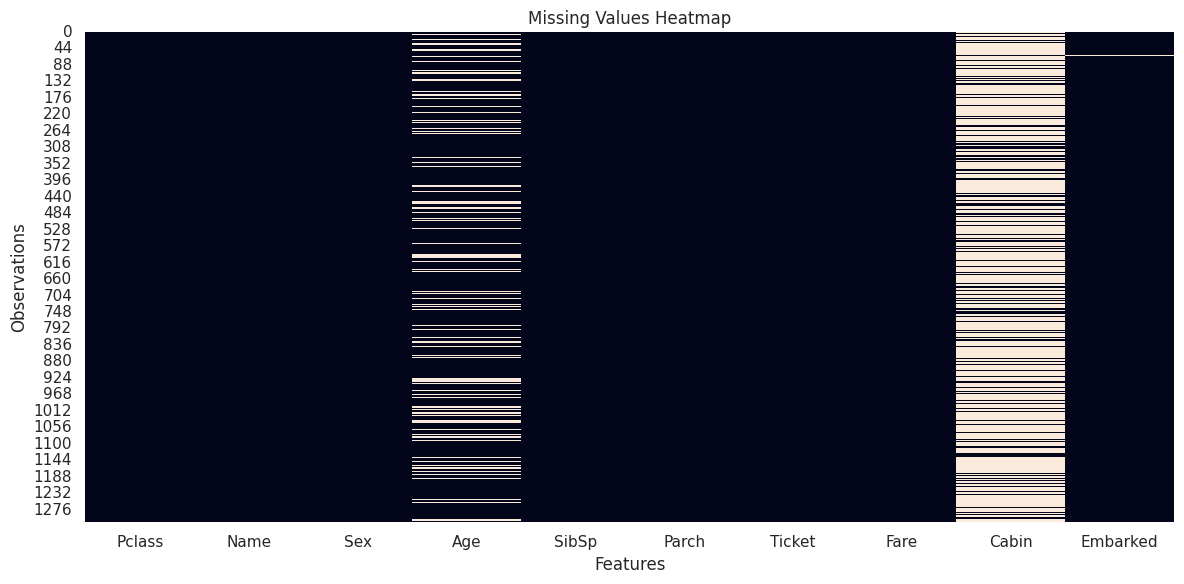

In [41]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df_full[features].isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Observations")

plt.tight_layout()
plt.show()

The heatmap above shows that the dataset contains relatively few missing values. Most features are complete, with only three columns requiring attention:

* `Cabin` has a large proportion of missing values. Because most entries are unavailable, we will exclude this feature from our analysis.
* `Embarked` has only a few missing values, which will be filled with the most frequent port of embarkation.
* `Age` contains a moderate number of missing values. Since age is likely to be an informative predictor of survival, we will impute the missing values rather than discard the affected rows. Before deciding on an imputation strategy, we will examine how the median age varies across different groups of passengers to determine whether a global median or a group-specific median is more appropriate.

### Choosing an Imputation Strategy for `Age`

A common baseline approach is to replace missing values with the global median age. However, passengers on the Titanic were not a homogeneous population. For example, age distributions may differ between passenger classes or between males and females. If these differences are substantial, using a single global median could introduce unnecessary bias.

To investigate this, we compare the median age computed:

* Across the entire dataset.
* Grouped by `Sex`.
* Grouped by `Pclass`.
* Grouped by both `Sex` and `Pclass`.

This comparison will help us determine whether a more granular imputation strategy is justified.

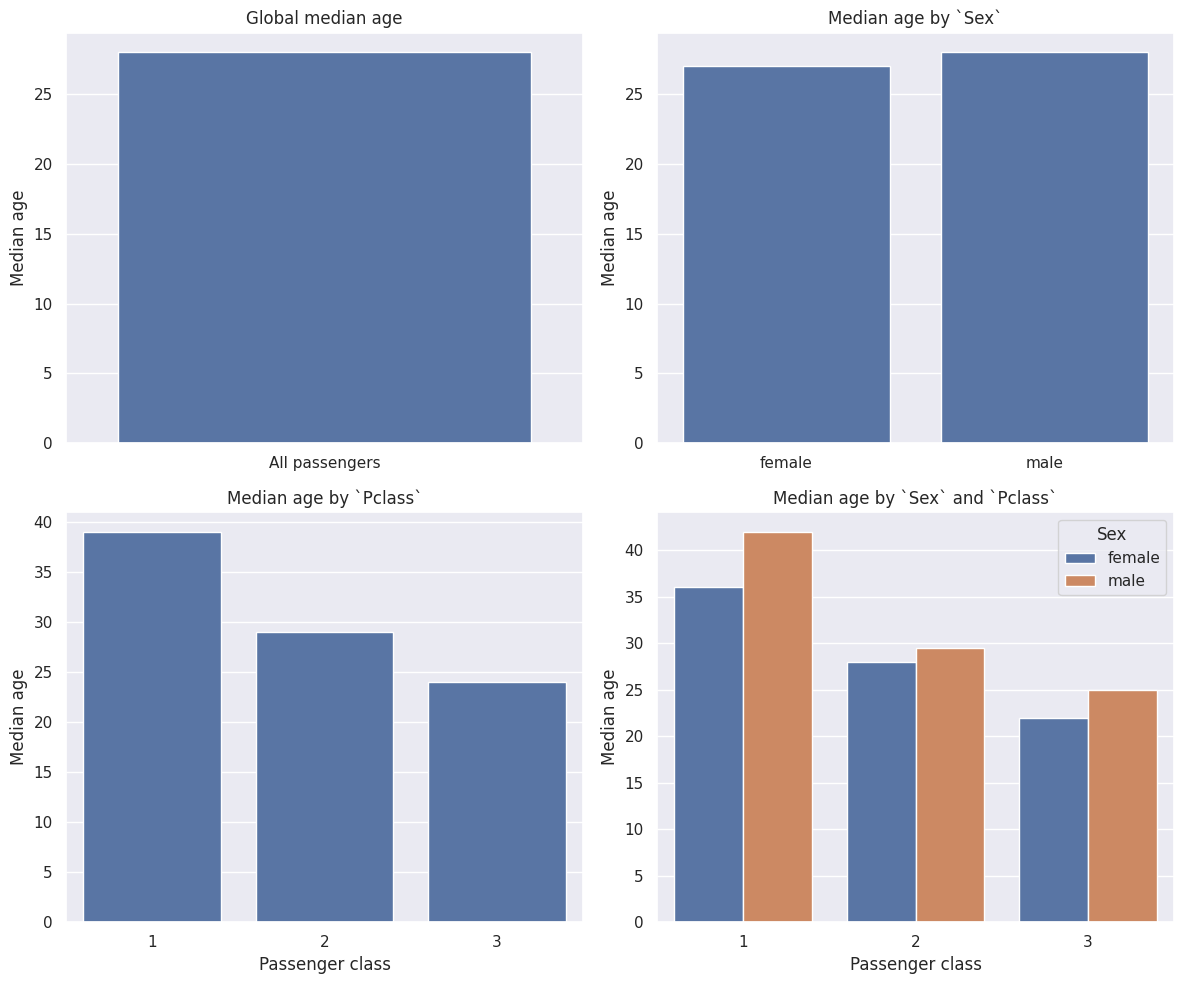

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Global median
global_median = df_full["Age"].median()

sns.barplot(
    x=["All passengers"],
    y=[global_median],
    ax=axes[0, 0]
)

axes[0, 0].set_title("Global median age")
axes[0, 0].set_ylabel("Median age")
axes[0, 0].set_xlabel("")

# Median by Sex
median_by_sex = (
    df_full
    .groupby("Sex")["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_sex,
    x="Sex",
    y="Age",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Median age by `Sex`")
axes[0, 1].set_ylabel("Median age")
axes[0, 1].set_xlabel("")

# Median by Pclass
median_by_class = (
    df_full
    .groupby("Pclass")["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_class,
    x="Pclass",
    y="Age",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Median age by `Pclass`")
axes[1, 0].set_ylabel("Median age")
axes[1, 0].set_xlabel("Passenger class")

# Median by Sex and Pclass
median_by_group = (
    df_full
    .groupby(["Pclass", "Sex"])["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_group,
    x="Pclass",
    y="Age",
    hue="Sex",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Median age by `Sex` and `Pclass`")
axes[1, 1].set_ylabel("Median age")
axes[1, 1].set_xlabel("Passenger class")

plt.tight_layout()
plt.show()

The plots above show that the median age varies considerably across passenger classes and, to a lesser extent, between males and females. While a single global median would provide a simple baseline, it would ignore these differences and assign the same age to passengers from groups with noticeably different age distributions.

Based on this analysis, we chose to impute missing values in `Age` using the median age computed within each (`Pclass`, `Sex`) group. This approach preserves more of the underlying structure of the data while remaining simple, interpretable, and computationally inexpensive.

In [43]:
df_full["Age"] = (
    df_full.groupby(["Pclass", "Sex"])["Age"]
           .transform(lambda s: s.fillna(s.median()))
)

### Fill missing values in `Embarked` with the mode

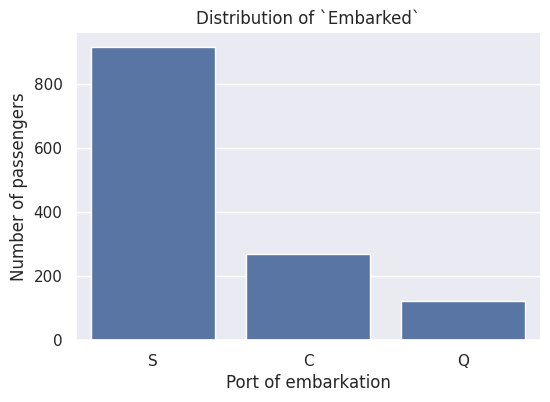

In [44]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_full,
    x="Embarked",
    order=df_full["Embarked"].value_counts().index
)

plt.title("Distribution of `Embarked`")
plt.xlabel("Port of embarkation")
plt.ylabel("Number of passengers")

plt.show()

The figure above shows that most passengers embarked at **Southampton (`S`)**, making it the mode of the `Embarked` feature by a large margin. Since only a few values are missing, replacing them with the most frequent category is a simple and reasonable imputation strategy that is unlikely to affect the overall distribution of the data.

In [45]:
# Fill missing values in `Embarked` with the most frequent category
embarked_mode = df_full["Embarked"].mode()[0]
df_full["Embarked"] = df_full["Embarked"].fillna(embarked_mode)

### Removing `Cabin`

The `Cabin` feature contains missing values for the majority of passengers. While it is possible to extract potentially useful information from the cabin identifier (such as the deck), the large proportion of missing entries would require more sophisticated imputation or feature engineering techniques.

For this tutorial, we choose to remove `Cabin` from the analysis and focus on features that are more complete and straightforward to preprocess. This simplifies the modeling pipeline while retaining the variables that carry most of the predictive information.

In [46]:
# Remove the `Cabin` column from the datasets
for df in [df_full, df_train, df_test]:
    if "Cabin" in df.columns:
        df.drop(columns="Cabin", inplace=True)

# Remove the `Cabin` row from the feature description table
df_features = df_features[df_features["Name"] != "Cabin"].reset_index(drop=True)

# Remove `Cabin` from the feature list
if "Cabin" in features:
    features.remove("Cabin")

df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


## Relationship Between Features and Survival

After handling the missing values, we can begin exploring how each feature relates to the target variable, `Survived`. The goal of this analysis is not to establish causal relationships, but rather to identify patterns that may help a classification model distinguish between passengers who survived and those who did not.

Throughout this section, we examine the distribution of survival across the available features and highlight variables that appear to carry predictive information. These observations will also guide the feature engineering and model development stages of the project.


### `Sex`

One of the first questions we can ask is whether passenger sex was associated with survival. Since `Sex` is a categorical variable, a simple comparison of survival rates between males and females provides an intuitive way to assess its predictive power.

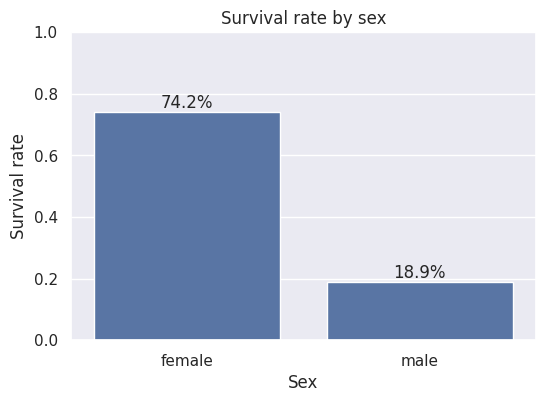

In [47]:
survival_by_sex = (
    df_train
    .groupby("Sex")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=survival_by_sex,
    x="Sex",
    y="Survived"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )


plt.title("Survival rate by sex")
plt.xlabel("Sex")
plt.ylabel("Survival rate")

plt.ylim(0, 1)

plt.show()


The figure above shows a striking difference in survival rates between male and female passengers. While only a small fraction of males survived, the majority of females did.

This pattern reflects the historical evacuation policy commonly described as *"women and children first"*, which prioritized women during the lifeboat evacuation. From a machine learning perspective, the result indicates that `Sex` is likely to be one of the most informative predictors of passenger survival and should therefore be retained as an important feature in our classification models.

### `Pclass`

Passenger class is often considered a proxy for socioeconomic status and may have influenced passengers' access to lifeboats and other resources during the evacuation. In this section, we examine how survival rates vary across the three passenger classes to determine whether `Pclass` is an informative predictor.

### `Age`

Age may have played an important role in survival, particularly given the historical accounts of evacuation procedures prioritizing women and children. Here, we investigate the relationship between passenger age and survival to determine whether age provides useful predictive information.

### `Fare`

The `Fare` feature represents the price paid for a passenger's ticket. Since ticket prices were generally associated with passenger class and cabin location, they may also be indirectly related to survival. We explore this relationship by comparing the fare distributions of survivors and non-survivors.

### `Embarked`

Passengers boarded the Titanic at one of three ports: Cherbourg (`C`), Queenstown (`Q`), or Southampton (`S`). Differences in passenger demographics across these ports may have influenced survival rates. We therefore compare the proportion of survivors for each port of embarkation.

### `SibSp`

The `SibSp` feature records the number of siblings and spouses traveling with each passenger. Traveling with family members may have influenced evacuation decisions and survival outcomes. In this section, we investigate whether the number of accompanying siblings or spouses is associated with survival.


### `Parch`

The `Parch` feature indicates the number of parents and children traveling with each passenger. Similar to `SibSp`, it provides information about family relationships aboard the Titanic. We examine whether traveling with parents or children is associated with differences in survival rates.

### `Ticket`

The `Ticket` feature contains the passenger's ticket number. Although it appears to be an identifier, ticket numbers may encode information about booking groups or travel arrangements. We perform a brief inspection to determine whether this feature contains useful predictive information in its raw form.

### `Name`

At first glance, the `Name` feature appears to be a simple identifier. However, passenger names contain additional information, such as honorific titles (`Mr.`, `Mrs.`, `Miss`, `Master`, etc.), which may capture demographic characteristics related to survival. We briefly examine this feature before exploring it further during feature engineering.

### Summary of Findings

The exploratory analysis reveals several features that appear to be strongly associated with passenger survival.

* `Sex` is the strongest individual predictor, with female passengers exhibiting substantially higher survival rates.
* `Pclass` is also highly informative, with first-class passengers surviving more frequently than those in second and third class.
* `Age` shows a weaker but noticeable relationship with survival, particularly for young children.
* `Fare` is positively associated with survival, although this relationship is partly explained by passenger class.
* `Embarked` exhibits modest differences in survival rates across ports of embarkation.
* `SibSp` and `Parch` suggest that family structure may influence survival, motivating the creation of derived features such as `FamilySize` and `IsAlone`.

These observations provide useful intuition about the dataset and motivate many of the feature engineering choices made in the next notebook.






## Summary statistics

## Target variable

## Univariate analysis

## Bivariate analysis

## Correlation analysis

## Initial conclusions